# UFC Winner Prediction — Modeling Pipeline (Pre-fight features only)

This notebook builds models to predict fight winners using **only pre-fight features** from `/mnt/data/ufc-master.csv`.

In [1]:
# 1. Setup
import pandas as pd, numpy as np
csv_path = "ufc-master.csv"
df = pd.read_csv(csv_path)
print("Loaded:", df.shape)
df.head()

Loaded: (6541, 118)


,RedFighter,BlueFighter,RedOdds,BlueOdds,RedExpectedValue,BlueExpectedValue,Date,Location,Country,Winner,...,FinishDetails,FinishRound,FinishRoundTime,TotalFightTimeSecs,RedDecOdds,BlueDecOdds,RSubOdds,BSubOdds,RKOOdds,BKOOdds
0,Colby Covington,Joaquin Buckley,205.0,-250.0,205.0000,40.0000,2024-12-14,"Tampa, Florida, USA",USA,Blue,...,NaN,3.0,4:42,882.0,300.0,175.0,1800.0,2000.0,1100.0,150.0
1,Cub Swanson,Billy Quarantillo,124.0,-148.0,124.0000,67.5676,2024-12-14,"Tampa, Florida, USA",USA,Red,...,Punch,3.0,1:36,696.0,250.0,NaN,1800.0,NaN,450.0,NaN
2,Manel Kape,Bruno Silva,-395.0,310.0,25.3165,310.0000,2024-12-14,"Tampa, Florida, USA",USA,Red,...,Punches,3.0,1:57,717.0,-105.0,550.0,900.0,1800.0,225.0,1100.0
3,Vitor Petrino,Dustin Jacoby,-340.0,270.0,29.4118,270.0000,2024-12-14,"Tampa, Florida, USA",USA,Blue,...,Punch,3.0,3:44,824.0,240.0,500.0,550.0,3000.0,110.0,800.0
4,Adrian Yanez,Daniel Marcos,185.0,-225.0,185.0000,44.4444,2024-12-14,"Tampa, Florida, USA",USA,Blue,...,NaN,3.0,5:00,900.0,450.0,150.0,2200.0,2200.0,450.0,200.0


In [2]:
# 2. Quick column inspection
print("Columns (first 80):", list(df.columns)[:80])
for key in ['Blue','Red','Dif','Odds','Stance','WeightClass','TitleBout','Reach','Height','Age']:
    cols = [c for c in df.columns if key in c]
    if cols:
        print(f"\nColumns containing '{key}': {cols[:10]}{'...' if len(cols)>10 else ''}")

Columns (first 80): ['RedFighter', 'BlueFighter', 'RedOdds', 'BlueOdds', 'RedExpectedValue', 'BlueExpectedValue', 'Date', 'Location', 'Country', 'Winner', 'TitleBout', 'WeightClass', 'Gender', 'NumberOfRounds', 'BlueCurrentLoseStreak', 'BlueCurrentWinStreak', 'BlueDraws', 'BlueAvgSigStrLanded', 'BlueAvgSigStrPct', 'BlueAvgSubAtt', 'BlueAvgTDLanded', 'BlueAvgTDPct', 'BlueLongestWinStreak', 'BlueLosses', 'BlueTotalRoundsFought', 'BlueTotalTitleBouts', 'BlueWinsByDecisionMajority', 'BlueWinsByDecisionSplit', 'BlueWinsByDecisionUnanimous', 'BlueWinsByKO', 'BlueWinsBySubmission', 'BlueWinsByTKODoctorStoppage', 'BlueWins', 'BlueStance', 'BlueHeightCms', 'BlueReachCms', 'BlueWeightLbs', 'RedCurrentLoseStreak', 'RedCurrentWinStreak', 'RedDraws', 'RedAvgSigStrLanded', 'RedAvgSigStrPct', 'RedAvgSubAtt', 'RedAvgTDLanded', 'RedAvgTDPct', 'RedLongestWinStreak', 'RedLosses', 'RedTotalRoundsFought', 'RedTotalTitleBouts', 'RedWinsByDecisionMajority', 'RedWinsByDecisionSplit', 'RedWinsByDecisionUnanimo

In [3]:
# 3. Create target and mark leakage columns
df['BlueWin'] = (df['Winner'] == 'Blue').astype(int)
leak_cols = [c for c in df.columns if any(x in c for x in ['Finish','FinishRound','FinishRoundTime','TotalFightTime','TotalFightTimeSecs'])]
print("Leak/post-fight columns detected:", leak_cols)

Leak/post-fight columns detected: ['Finish', 'FinishDetails', 'FinishRound', 'FinishRoundTime', 'TotalFightTimeSecs']


In [6]:
# 4. Select pre-fight features programmatically
cols = df.columns.tolist()
exclude = set(['Winner','BlueWin','RedFighter','BlueFighter','Date','Location','EmptyArena', 'Country'])
exclude |= set([c for c in cols if any(x in c for x in ['Finish','TotalFightTime','Referee', 'weightRank', 'FPRank', 'WinsBy'])])
exclude |= set(leak_cols)
include_keywords = ['Blue','Red','Dif','Odds','Implied','Age','Reach','Height','Weight','Stance','Rank','TitleBout','WeightClass','NumberOfRounds','Country','Gender']

feature_cols = [c for c in cols if (c not in exclude) and any(k in c for k in include_keywords)]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]
categorical_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
print("Selected features:", len(feature_cols), "\n", feature_cols)
print("Numeric sample:", numeric_cols[:20])
print("Categorical sample:", categorical_cols[:20])

Selected features: 68 
 ['RedOdds', 'BlueOdds', 'RedExpectedValue', 'BlueExpectedValue', 'TitleBout', 'WeightClass', 'Gender', 'NumberOfRounds', 'BlueCurrentLoseStreak', 'BlueCurrentWinStreak', 'BlueDraws', 'BlueAvgSigStrLanded', 'BlueAvgSigStrPct', 'BlueAvgSubAtt', 'BlueAvgTDLanded', 'BlueAvgTDPct', 'BlueLongestWinStreak', 'BlueLosses', 'BlueTotalRoundsFought', 'BlueTotalTitleBouts', 'BlueWins', 'BlueStance', 'BlueHeightCms', 'BlueReachCms', 'BlueWeightLbs', 'RedCurrentLoseStreak', 'RedCurrentWinStreak', 'RedDraws', 'RedAvgSigStrLanded', 'RedAvgSigStrPct', 'RedAvgSubAtt', 'RedAvgTDLanded', 'RedAvgTDPct', 'RedLongestWinStreak', 'RedLosses', 'RedTotalRoundsFought', 'RedTotalTitleBouts', 'RedWins', 'RedStance', 'RedHeightCms', 'RedReachCms', 'RedWeightLbs', 'RedAge', 'BlueAge', 'LoseStreakDif', 'WinStreakDif', 'LongestWinStreakDif', 'WinDif', 'LossDif', 'TotalRoundDif', 'TotalTitleBoutDif', 'KODif', 'SubDif', 'HeightDif', 'ReachDif', 'AgeDif', 'SigStrDif', 'AvgSubAttDif', 'AvgTDDif', 'BM

In [7]:
from sklearn.model_selection import train_test_split
X = df[feature_cols].copy()
y = df['BlueWin'].copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Train/test:", X_train.shape, X_test.shape)

Train/test: (5232, 68) (1309, 68)


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_cols),
                                  ('cat', categorical_transformer, categorical_cols)], sparse_threshold=0)

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
models = {
    'LogisticRegression': Pipeline([('pre', preprocessor), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))]),
    'RandomForest': Pipeline([('pre', preprocessor), ('clf', RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42))]),
    'GradientBoosting': Pipeline([('pre', preprocessor), ('clf', GradientBoostingClassifier(n_estimators=200, random_state=42))]),
    'MLP': Pipeline([('pre', preprocessor), ('clf', MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=42))])
}
# Try to add XGBoost if available
try:
    from xgboost import XGBClassifier
    models['XGBoost'] = Pipeline([('pre', preprocessor), ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))])
    print("XGBoost added")
except Exception as e:
    print("XGBoost not available:", e)

XGBoost added


In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy','f1','roc_auc']

import numpy as np
for name, model in models.items():
    print("\nModel:", name)
    try:
        acc = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
        f1 = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
        roc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
        print("Accuracy: %.4f ± %.4f" % (acc.mean(), acc.std()))
        print("F1: %.4f ± %.4f" % (f1.mean(), f1.std()))
        print("ROC AUC: %.4f ± %.4f" % (roc.mean(), roc.std()))
    except Exception as e:
        print("Error CV for", name, e)


Model: LogisticRegression


Accuracy: 0.6397 ± 0.0132
F1: 0.6027 ± 0.0147
ROC AUC: 0.7011 ± 0.0146

Model: RandomForest
Accuracy: 0.6577 ± 0.0113
F1: 0.5512 ± 0.0159
ROC AUC: 0.6957 ± 0.0132

Model: GradientBoosting
Accuracy: 0.6432 ± 0.0122
F1: 0.5367 ± 0.0175
ROC AUC: 0.6881 ± 0.0125

Model: MLP
Accuracy: 0.5866 ± 0.0073
F1: 0.4977 ± 0.0119
ROC AUC: 0.6092 ± 0.0129

Model: XGBoost


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [11:24:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [11:24:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [11:24:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [11:24:09] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iterati

Accuracy: 0.6223 ± 0.0103
F1: 0.5235 ± 0.0130
ROC AUC: 0.6580 ± 0.0135


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
results = []
for name, model in models.items():
    print("\nTraining:", name)
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        if hasattr(model.named_steps['clf'], 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:,1]
        else:
            y_proba = None
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc = roc_auc_score(y_test, y_proba) if y_proba is not None else float('nan')
        print(f"Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f} | ROC-AUC: {roc:.4f}")
        print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
        results.append({'model': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'roc_auc': roc})
    except Exception as e:
        print("Error training/evaluating", name, e)

import pandas as pd
print("\nSummary:")
display(pd.DataFrame(results).set_index('model').sort_values('f1', ascending=False))


Training: LogisticRegression
Acc: 0.6524 | Prec: 0.5753 | Rec: 0.6600 | F1: 0.6147 | ROC-AUC: 0.7176
Confusion matrix:
 [[491 268]
 [187 363]]

Training: RandomForest
Acc: 0.6440 | Prec: 0.5977 | Rec: 0.4673 | F1: 0.5245 | ROC-AUC: 0.7062
Confusion matrix:
 [[586 173]
 [293 257]]

Training: GradientBoosting
Acc: 0.6593 | Prec: 0.6209 | Rec: 0.4855 | F1: 0.5449 | ROC-AUC: 0.7124
Confusion matrix:
 [[596 163]
 [283 267]]

Training: MLP
Acc: 0.5882 | Prec: 0.5102 | Rec: 0.5000 | F1: 0.5051 | ROC-AUC: 0.6102
Confusion matrix:
 [[495 264]
 [275 275]]

Training: XGBoost
Acc: 0.6417 | Prec: 0.5842 | Rec: 0.5109 | F1: 0.5451 | ROC-AUC: 0.6973
Confusion matrix:
 [[559 200]
 [269 281]]

Summary:


/opt/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [11:24:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.652406,0.575277,0.660000,0.614733,0.717566
XGBoost,0.641711,0.584200,0.510909,0.545102,0.697329
GradientBoosting,0.659282,0.620930,0.485455,0.544898,0.712428
RandomForest,0.644003,0.597674,0.467273,0.524490,0.706202
MLP,0.588235,0.510204,0.500000,0.505051,0.610248


BlueExpectedValue        0.044310
RedExpectedValue         0.043842
BlueOdds                 0.040854
RedOdds                  0.040054
BlueDecOdds              0.026729
SigStrDif                0.024664
BKOOdds                  0.024070
RedDecOdds               0.023545
RedAvgSigStrLanded       0.023494
BlueAvgSigStrPct         0.023172
AvgTDDif                 0.023045
RedAvgSigStrPct          0.022849
RSubOdds                 0.022428
RKOOdds                  0.022189
BSubOdds                 0.021733
BlueAvgSigStrLanded      0.021271
RedAvgTDLanded           0.019908
RedAvgTDPct              0.019115
AvgSubAttDif             0.018807
AgeDif                   0.018480
BlueAvgTDLanded          0.018088
BlueAge                  0.017884
TotalRoundDif            0.017387
RedAge                   0.017244
BlueAvgTDPct             0.016814
ReachDif                 0.016485
RedTotalRoundsFought     0.016060
RedReachCms              0.015506
HeightDif                0.015017
BlueReachCms  

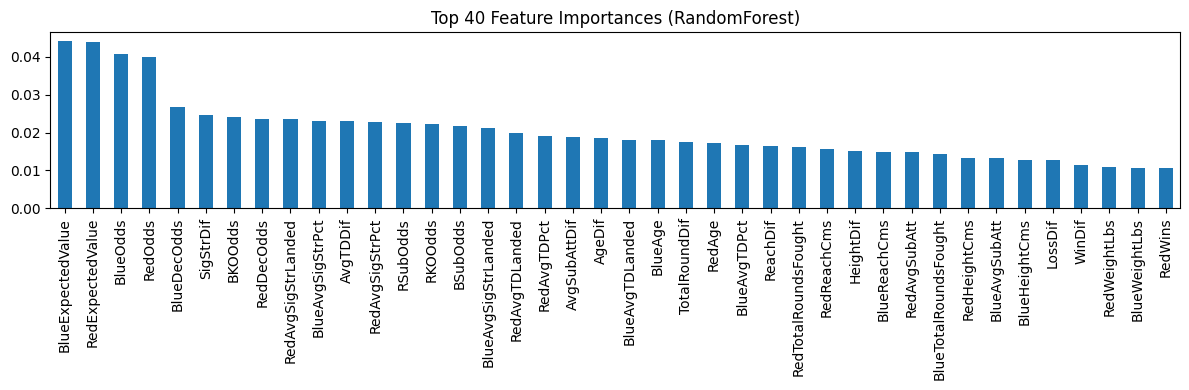

In [13]:
import matplotlib.pyplot as plt
# Feature importances for tree-based models (example for RandomForest)
def get_feature_names(preprocessor):
    num_names = list(preprocessor.transformers_[0][2])
    cat_trans = preprocessor.transformers_[1][1]
    if hasattr(cat_trans.named_steps['ohe'], 'get_feature_names_out'):
        cat_names = list(cat_trans.named_steps['ohe'].get_feature_names_out(preprocessor.transformers_[1][2]))
    else:
        cat_names = []
    return num_names + cat_names

if 'RandomForest' in models:
    try:
        rf = models['RandomForest']
        pre = rf.named_steps['pre']
        clf = rf.named_steps['clf']
        feat_names = get_feature_names(pre)
        imp = clf.feature_importances_
        importances = pd.Series(imp, index=feat_names).sort_values(ascending=False).head(40)
        display(importances)
        importances.plot(kind='bar', figsize=(12,4))
        plt.title('Top 40 Feature Importances (RandomForest)')
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print("Could not compute feature importances:", e)